In [41]:
import numpy as np
import networkx as nx
import pandas as pd
from tqdm.auto import tqdm
import itertools
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from LSAS.LSAS import alg_LSAS
from networkx.algorithms.d_separation import is_d_separator

## Generate synthetic data

In [42]:
def generate_dataset_fig3(n, rng):
    nodes_fig3 = ["V1", "V6", "V7", "U1", "U2", "V2", "V3", "X", "V4", "V5", "Y"]
    latent_nodes = ["U1", "U2"]
    observed_nodes = [node for node in nodes_fig3 if node not in latent_nodes]

    B = pd.DataFrame(0, index=nodes_fig3, columns=nodes_fig3, dtype=float)

    B.loc['V1', 'V2'] = rng.uniform(0.5, 1.5)
    B.loc['V1', 'Y']  = rng.uniform(0.5, 1.5)
    B.loc['V1', 'X']  = rng.uniform(0.5, 1.5)
    B.loc['V2', 'Y']  = rng.uniform(0.5, 1.5)
    B.loc['V2', 'X']  = rng.uniform(0.5, 1.5)
    B.loc['V6', 'X']  = rng.uniform(0.5, 1.5)
    B.loc['V6', 'V7'] = rng.uniform(0.5, 1.5)
    B.loc['V4', 'Y']  = rng.uniform(0.5, 1.5)
    B.loc['V4', 'V5'] = rng.uniform(0.5, 1.5)
    B.loc['X', 'Y']   = rng.uniform(0.5, 1.5)
    B.loc['U1', 'V3'] = rng.uniform(0.5, 1.5)
    B.loc['U1', 'X']  = rng.uniform(0.5, 1.5)
    B.loc['U2', 'V3'] = rng.uniform(0.5, 1.5)
    B.loc['U2', 'Y']  = rng.uniform(0.5, 1.5)

    E = pd.DataFrame(
        rng.normal(0, 1, size=(n, len(nodes_fig3))),
        columns=nodes_fig3
    )

    D_full = pd.DataFrame(0, index=np.arange(n), columns=nodes_fig3, dtype=float)

    for node in nodes_fig3:
        parents = B.index[B[node] != 0].tolist()
        if len(parents) == 0:
            D_full[node] = E[node].values
        else:
            D_full[node] = D_full[parents].values @ B.loc[parents, node].values + E[node].values

    D_obs = D_full[observed_nodes].copy()

    B_np = B.loc[nodes_fig3, nodes_fig3].values
    total_effect_matrix = np.linalg.inv(np.eye(len(nodes_fig3)) - B_np) - np.eye(len(nodes_fig3))

    x_idx = nodes_fig3.index("X")
    y_idx = nodes_fig3.index("Y")
    true_ce = total_effect_matrix[x_idx, y_idx]

    return D_obs, B, true_ce

In [43]:
def generate_dataset_fig4(n, rng):
    nodes_fig4 = [
        "U1", "U2", "U3", "U4",
        "V4", "V7", "V9",
        "V5", "V6", "V2",
        "X", "V8", "V1",
        "Y", "V3"
    ]

    treatment = 'X'
    outcome = 'Y'

    latent_nodes = ["U1", "U2", "U3", "U4"]
    observed_nodes = [n for n in nodes_fig4 if n not in latent_nodes]

    B = pd.DataFrame(0, index=nodes_fig4, columns=nodes_fig4, dtype=float)

    B.loc['U4', 'V5'] = rng.uniform(0.5, 1.5)
    B.loc['U4', 'V6'] = rng.uniform(0.5, 1.5)
    B.loc['V7', 'V6'] = rng.uniform(0.5, 1.5)
    B.loc['V6', 'Y'] = rng.uniform(0.5, 1.5)
    B.loc['V5', 'Y'] = rng.uniform(0.5, 1.5)
    B.loc['U3', 'V5'] = rng.uniform(0.5, 1.5)
    B.loc['U3', 'X'] = rng.uniform(0.5, 1.5)
    B.loc['V2', 'V3'] = rng.uniform(0.5, 1.5)
    B.loc['V2', 'Y'] = rng.uniform(0.5, 1.5)
    B.loc['V9', 'Y'] = rng.uniform(0.5, 1.5)
    B.loc['V9', 'V8'] = rng.uniform(0.5, 1.5)
    B.loc['X', 'Y'] = rng.uniform(0.5, 1.5)
    B.loc['U1', 'V1'] = rng.uniform(0.5, 1.5)
    B.loc['U1', 'X'] = rng.uniform(0.5, 1.5)
    B.loc['U2', 'V1'] = rng.uniform(0.5, 1.5)
    B.loc['U2', 'Y'] = rng.uniform(0.5, 1.5)
    B.loc['V8', 'X'] = rng.uniform(0.5, 1.5)
    B.loc['V8', 'Y'] = rng.uniform(0.5, 1.5)

    E = pd.DataFrame(
        rng.normal(0, 1, size=(n, len(nodes_fig4))),
        columns=nodes_fig4
    )

    D_full = pd.DataFrame(0, index=np.arange(n), columns=nodes_fig4, dtype=float)

    for node in nodes_fig4:
        parents = B.index[B[node] != 0].tolist()
        if len(parents) == 0:
            D_full[node] = E[node].values
        else:
            D_full[node] = D_full[parents].values @ B.loc[parents, node].values + E[node].values

    D_obs = D_full[observed_nodes].copy()

    B_np = B.loc[nodes_fig4, nodes_fig4].values
    total_effect_matrix = np.linalg.inv(np.eye(len(nodes_fig4)) - B_np) - np.eye(len(nodes_fig4))

    x_idx = nodes_fig4.index("X")
    y_idx = nodes_fig4.index("Y")
    true_ce = total_effect_matrix[x_idx, y_idx]

    return D_obs, B, true_ce

## Helper functions

In [44]:
def ci_test(X, Y, Z, D_obs, alpha = 0.05):
    '''
    Returns true if X and Y are conditionally independent given Z, false otherwise.
    '''
    x = D_obs[X].to_numpy(dtype=float)
    y = D_obs[Y].to_numpy(dtype=float)

    if len(Z) == 0:
        stat, p_value = pearsonr(x, y)
        return p_value > alpha, p_value, stat
    
    Z_mat = D_obs[Z].to_numpy(dtype=float)
    Z_mat = np.column_stack([np.ones(len(D_obs)), Z_mat])

    beta_x = np.linalg.lstsq(Z_mat, x, rcond=None)[0]
    beta_y = np.linalg.lstsq(Z_mat, y, rcond=None)[0]

    resid_x = x - Z_mat @ beta_x
    resid_y = y - Z_mat @ beta_y

    stat, p_value = pearsonr(resid_x, resid_y)
    return p_value > alpha, p_value, stat

In [45]:
def r1(w, Z, D_obs, x = 'X', y = 'Y', alpha_dep = 0.01, alpha_indep = 0.1):
    Z = list(Z)
    Z_plus_x = Z + [x]

    indep1, pval1, stat1 = ci_test(w, y, Z, D_obs, alpha_dep)
    indep2, pval2, stat2 = ci_test(w, y, Z_plus_x, D_obs, alpha_indep)

    cond_1 = not indep1
    cond_2 = indep2

    return {
        "R1": cond_1 and cond_2,
        "w": w,
        "Z": list(Z),
        "cond1_dep_given_Z": cond_1,
        "cond2_indep_given_Z_plus_x": cond_2,
        "pval1": pval1,
        "pval2": pval2,
        "stat1": stat1,
        "stat2": stat2
    }

In [46]:
def r2(w, Z, D_obs, x='X', y='Y', alpha_dep=0.01, alpha_indep=0.1):
    Z = list(Z)

    indep1, pval1, stat1 = ci_test(w, x, Z, D_obs, alpha_dep)
    indep2, pval2, stat2 = ci_test(w, y, Z, D_obs, alpha_indep)

    cond_1 = not indep1
    cond_2 = indep2

    return {
        "R2": cond_1 and cond_2,
        "w": w,
        "Z": list(Z),
        "cond1_dep_w_x_given_Z": cond_1,
        "cond2_indep_w_y_given_Z": cond_2,
        "pval1": pval1,
        "pval2": pval2,
        "stat1": stat1,
        "stat2": stat2
    }

In [47]:
def r2a(Z, D_obs, x='X', y='Y', alpha_indep=0.1):
    Z = list(Z)

    indep_xy, pval, stat = ci_test(x, y, Z, D_obs, alpha_indep)

    return {
        "R2a": indep_xy,
        "Z": list(Z),
        "cond_indep_x_y_given_Z": indep_xy,
        "pval": pval,
        "stat": stat
    }

In [48]:
def estimate_ate_linear(D_obs, x='X', y='Y', Z=None):
    if Z is None:
        Z = []

    predictors = [x] + list(Z)
    X_mat = sm.add_constant(D_obs[predictors])
    model = sm.OLS(D_obs[y], X_mat).fit()

    return model.params[x]

In [49]:
def alg_EHS(D_obs, x='X', y='Y', alpha_dep=0.01, alpha_indep=0.1, max_z_size=None):
    W = [col for col in D_obs.columns if col not in [x, y]]
    if max_z_size is None:
        max_z_size = len(W)
    
    VASs = []
    R1_count = 0
    R2_count = 0
    R2a_count = 0
    CI_num = 0

    # R2 i)
    for k in range(max_z_size + 1):
        for Z in itertools.combinations(W, k):
            Z = list(Z)

            out_r2a = r2a(Z, D_obs, x=x, y=y, alpha_indep=alpha_indep)
            CI_num += 1

            if out_r2a["R2a"]:
                R2_count += 1
                R2a_count += 1

    # R1 i)
    for k in range(max_z_size + 1):
        for Z in itertools.combinations(W, k):
            Z = list(Z)
            for w in W:
                if w in Z:
                    continue
                out_r1 = r1(w, Z, D_obs, x, y, alpha_dep, alpha_indep)
                CI_num += 2

                if out_r1["R1"]:
                    R1_count += 1
                    if Z not in VASs:
                        VASs.append(Z)

                out_r2 = r2(w, Z, D_obs, x, y, alpha_dep, alpha_indep)
                CI_num += 2

                if out_r2["R2"]:
                    R2_count += 1


    if R1_count > 0 and R2_count > 0:
        decision = '?'
        ate = None
    elif R1_count > 0:
        ates = [estimate_ate_linear(D_obs, x, y, Z) for Z in VASs]
        ate = float(np.mean(ates)) if len(ates) > 0 else None
        decision = '+'
    elif R2_count > 0:
        decision = '0'
        ate = 0.0
    else:
        decision = '?'
        ate = None
    return {
        "decision": decision,
        "VASs": VASs,
        "ATE": ate,
        "CI_num": CI_num,
        "R1_count": R1_count,
        "R2_count": R2_count
    }

In [50]:
def alg_ea_pc(D_obs, x='X', y='Y', max_z_size= None, alpha=0.01):
    
    observed_nodes = D_obs.columns.tolist()
    W = [node for node in observed_nodes if node not in [x, y]]

    skeleton = nx.Graph()
    skeleton.add_nodes_from(observed_nodes)

    for i, a in enumerate(skeleton.nodes):
        for b in list(skeleton.nodes)[i+1:]:
            skeleton.add_edge(a, b)

    ci_cache = {}
    sepsets = {}

    r1_hits = []
    r2_hits = []

    n_ci_requests = 0
    n_ci_executed = 0
    r1_count = 0
    r2_count = 0

    if max_z_size is None:
        max_z_size = len(skeleton.nodes) - 2
    else:
        max_z_size = min(max_z_size, len(skeleton.nodes) - 2)

    for l in range(max_z_size + 1):
        any_test_possible_this_round = False
        pairs_to_check = list(skeleton.edges())

        for A, B in pairs_to_check:
            if not skeleton.has_edge(A, B):
                continue

            adjA = [n for n in skeleton.neighbors(A) if n != B]
            adjB = [n for n in skeleton.neighbors(B) if n != A]

            if len(adjA) < l and len(adjB) < l:
                continue

            any_test_possible_this_round = True

            candidate_sets = set()

            if len(adjA) >= l:
                for Z in itertools.combinations(adjA, l):
                    candidate_sets.add(tuple(sorted(Z)))

            if len(adjB) >= l:
                for Z in itertools.combinations(adjB, l):
                    candidate_sets.add(tuple(sorted(Z)))

            for Z in candidate_sets:
                Z = tuple(sorted(Z))
                key = (A, B, Z)

                n_ci_requests += 1

                if key not in ci_cache:
                    n_ci_executed += 1
                    indep, p_value, stat = ci_test(A, B, list(Z), D_obs, alpha=alpha)
                    ci_cache[key] = indep
                    ci_cache[(B, A, Z)] = indep

                indep = ci_cache[key]

                pair_is_xy = set([A, B]) == set([x, y])
                pair_is_wy = ((A in W and B == y) or (B in W and A == y))
                pair_is_wx = ((A in W and B == x) or (B in W and A == x))

                # Standard PC skeleton update
                if indep and skeleton.has_edge(A, B):
                    skeleton.remove_edge(A, B)
                    sepsets[frozenset([A, B])] = list(Z)

                # Rule 2a
                if pair_is_xy and indep:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2a",
                        "Z": list(Z)
                    })

                # Rule 1 hook
                if pair_is_wy and (not indep) and (x not in Z):
                    w = A if A in W else B
                    Z_plus_x = tuple(sorted(list(Z) + [x]))
                    key_r1 = (w, y, Z_plus_x)

                    n_ci_requests += 1

                    if key_r1 not in ci_cache:
                        n_ci_executed += 1
                        indep_r1_followup, p_value, stat = ci_test(w, y, list(Z_plus_x), D_obs, alpha=alpha)
                        ci_cache[key_r1] = indep_r1_followup
                        ci_cache[(y, w, Z_plus_x)] = indep_r1_followup

                    indep_r1_followup = ci_cache[key_r1]

                    if indep_r1_followup:
                        r1_count += 1
                        r1_hits.append({
                            "reason": "R1",
                            "w": w,
                            "Z": list(Z)
                        })

                # Rule 2 hook from cache
                if pair_is_wy and indep:
                    w = A if A in W else B
                    key_wx = (w, x, Z)

                    if key_wx in ci_cache and ci_cache[key_wx] is False:
                        r2_count += 1
                        r2_hits.append({
                            "reason": "R2",
                            "w": w,
                            "Z": list(Z)
                        })

                if pair_is_wx and (not indep):
                    w = A if A in W else B
                    key_wy = (w, y, Z)

                    if key_wy in ci_cache and ci_cache[key_wy] is True:
                        r2_count += 1
                        found = {
                            "decision": "0",
                            "reason": "R2",
                            "w": w,
                            "Z": list(Z)
                        }


        if not any_test_possible_this_round:
            break

    if len(r1_hits) > 0 and len(r2_hits) > 0:
        decision = "?"
        vas_list = [hit["Z"] for hit in r1_hits]
        ate = None

    elif len(r1_hits) > 0:
        decision = "+"
        vas_list = []

        for hit in r1_hits:
            if hit["Z"] not in vas_list:
                vas_list.append(hit["Z"])

        ates = [estimate_ate_linear(D_obs, x=x, y=y, Z=Z) for Z in vas_list]
        ate = float(np.mean(ates)) if len(ates) > 0 else None

    elif len(r2_hits) > 0:
        decision = "0"
        vas_list = []
        ate = 0.0

    else:
        decision = "?"
        vas_list = []
        ate = None

    return {
        "decision": decision,
        "VASs": vas_list,
        "ATE": ate,
        "CI_num": n_ci_requests,
        "CI_num_executed": n_ci_executed,
        "R1_count": r1_count,
        "R2_count": r2_count,
        "r1_hits": r1_hits,
        "r2_hits": r2_hits,
        "sepsets": sepsets
    }

In [51]:
def run_structure_experiment(
    generator,
    structure_name,
    structure_id,
    sample_sizes=[1000, 5000, 10000, 15000],
    n_reps=100,
    treatment="X",
    outcome="Y",
    alpha_dep=0.01,
    alpha_indep=0.01,
    alpha_pc=0.01
):
    results = []

    for n in sample_sizes:
        tqdm.write(f"Running {structure_name} with sample size {n} for {n_reps} reps...")

        for rep in tqdm(range(n_reps), desc=f"Processing {structure_name}", leave=True, position=0):

            seed_seq = np.random.SeedSequence([12345, structure_id, n, rep])
            D_obs, B, true_ce = generator(n, np.random.default_rng(seed_seq))

            # -------- EHS --------
            res_ehs = alg_EHS(
                D_obs,
                x=treatment,
                y=outcome,
                max_z_size=None,
                alpha_dep=alpha_dep,
                alpha_indep=alpha_indep
            )

            estimated_ce = res_ehs["ATE"]
            RE = None if estimated_ce is None else abs(estimated_ce - true_ce) / abs(true_ce)

            results.append({
                "method": "EHS",
                "structure": structure_name,
                "sample_size": n,
                "rep": rep,
                "decision": res_ehs["decision"],
                "true_ce": true_ce,
                "estimated_ce": estimated_ce,
                "RE": RE,
                "nTest": res_ehs["CI_num"],
                "VASs": res_ehs["VASs"],
                "R1_count": res_ehs["R1_count"],
                "R2_count": res_ehs["R2_count"]
            })

            # -------- PC-EA --------
            res_pc_ea = alg_ea_pc(
                D_obs,
                x=treatment,
                y=outcome,
                max_z_size=None,
                alpha=alpha_pc
            )

            estimated_ce = res_pc_ea["ATE"]
            RE = None if estimated_ce is None else abs(estimated_ce - true_ce) / abs(true_ce)

            results.append({
                "method": "PC-EA",
                "structure": structure_name,
                "sample_size": n,
                "rep": rep,
                "decision": res_pc_ea["decision"],
                "true_ce": true_ce,
                "estimated_ce": estimated_ce,
                "RE": RE,
                "nTest": res_pc_ea["CI_num_executed"],
                "VASs": res_pc_ea["VASs"],
                "R1_count": res_pc_ea["R1_count"],
                "R2_count": res_pc_ea["R2_count"]
            })

            # -------- LSAS --------
            res_lsas = alg_LSAS(D_obs, Tr_X=treatment, Out_Y=outcome)

            VASs_lsas = res_lsas["VASs"]
            estimated_ce = res_lsas["ATE"]

            if VASs_lsas is None:
                decision = "?"
            elif VASs_lsas == 0:
                decision = "0"
            else:
                decision = "+"

            RE = None if estimated_ce is None else abs(estimated_ce - true_ce) / abs(true_ce)

            results.append({
                "method": "LSAS",
                "structure": structure_name,
                "sample_size": n,
                "rep": rep,
                "decision": decision,
                "true_ce": true_ce,
                "estimated_ce": estimated_ce,
                "RE": RE,
                "nTest": res_lsas["CI_num"],
                "VASs": VASs_lsas,
                "R1_count": None,
                "R2_count": None
            })

    return pd.DataFrame(results)

## Run Experiment

### Experiments Figure 3

In [52]:
results_fig3 = run_structure_experiment(
    generate_dataset_fig3,
    structure_name="figure3",
    structure_id = 3
)

Running figure3 with sample size 1000 for 100 reps...


Processing figure3: 100%|██████████| 100/100 [01:14<00:00,  1.33it/s]


Running figure3 with sample size 5000 for 100 reps...


Processing figure3: 100%|██████████| 100/100 [02:12<00:00,  1.33s/it]


Running figure3 with sample size 10000 for 100 reps...


Processing figure3: 100%|██████████| 100/100 [03:13<00:00,  1.93s/it]


Running figure3 with sample size 15000 for 100 reps...


Processing figure3: 100%|██████████| 100/100 [04:06<00:00,  2.47s/it]


In [53]:
summary = (
    results_fig3
    .groupby(['method', "sample_size"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

summary

,method,sample_size,mean_RE,std_RE,mean_nTest,std_nTest
0,EHS,1000,0.148046,0.145100,1920.00,0.000000
1,EHS,5000,0.113838,0.136439,1920.00,0.000000
2,EHS,10000,0.079160,0.157631,1920.00,0.000000
3,EHS,15000,0.097934,0.135367,1920.00,0.000000
4,LSAS,1000,0.071921,0.080212,74.53,19.390956
5,LSAS,5000,0.059716,0.117319,114.48,31.705870
6,LSAS,10000,0.053280,0.141852,131.50,28.906502
7,LSAS,15000,0.064929,0.118580,140.54,24.848397
8,PC-EA,1000,0.270358,0.299341,201.40,36.009258
9,PC-EA,5000,0.132283,0.175716,254.21,31.264365


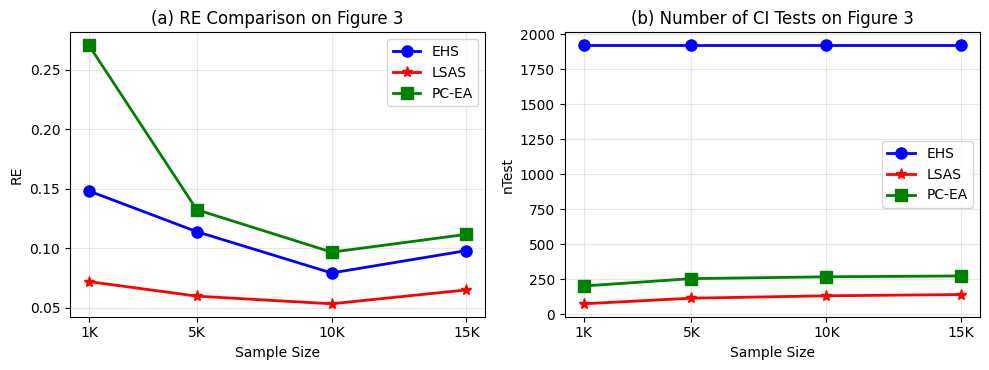

In [54]:
method_styles = {
    "LSAS": {
        "color": "red",
        "marker": "*"
    },
    "EHS": {
        "color": "blue",
        "marker": "o"
    },
    "PC-EA": {
        "color": "green",
        "marker": "s" 
    }
}

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

for method in summary["method"].unique():
    df_method = summary[summary["method"] == method]

    style = method_styles.get(
        method,
        {"color": "black", "marker": "o"}
    )

    # RE 
    axes[0].plot(
        df_method["sample_size"],
        df_method["mean_RE"],
        marker=style["marker"],
        color=style["color"],
        linewidth=2,
        markersize=8,
        label=method
    )

    # nTest 
    axes[1].plot(
        df_method["sample_size"],
        df_method["mean_nTest"],
        marker=style["marker"],
        color=style["color"],
        linewidth=2,
        markersize=8,
        label=method
    )

axes[0].set_xlabel("Sample Size")
axes[0].set_ylabel("RE")
axes[0].set_title("(a) RE Comparison on Figure 3")
axes[0].set_xticks(sorted(summary["sample_size"].unique()))
axes[0].set_xticklabels(["1K", "5K", "10K", "15K"])
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_xlabel("Sample Size")
axes[1].set_ylabel("nTest")
axes[1].set_title("(b) Number of CI Tests on Figure 3")
axes[1].set_xticks(sorted(summary["sample_size"].unique()))
axes[1].set_xticklabels(["1K", "5K", "10K", "15K"])
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### Experiments Figure 4

In [55]:
results_fig4 = run_structure_experiment(
    generate_dataset_fig4,
    structure_name="figure4",
    structure_id = 4
)

Running figure4 with sample size 1000 for 100 reps...


Processing figure4: 100%|██████████| 100/100 [20:44<00:00, 12.45s/it]  


Running figure4 with sample size 5000 for 100 reps...


Processing figure4: 100%|██████████| 100/100 [11:53<00:00,  7.13s/it]


Running figure4 with sample size 10000 for 100 reps...


Processing figure4: 100%|██████████| 100/100 [18:05<00:00, 10.86s/it]


Running figure4 with sample size 15000 for 100 reps...


Processing figure4: 100%|██████████| 100/100 [24:32<00:00, 14.72s/it]


In [56]:
summary_fig_4 = (
    results_fig4
    .groupby(['method', "sample_size"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

summary_fig_4

,method,sample_size,mean_RE,std_RE,mean_nTest,std_nTest
0,EHS,1000,0.317557,0.319599,9728.00,0.000000
1,EHS,5000,0.265879,0.343146,9728.00,0.000000
2,EHS,10000,0.147981,0.237281,9728.00,0.000000
3,EHS,15000,0.089727,0.158980,9728.00,0.000000
4,LSAS,1000,0.300877,0.191578,521.93,103.423934
5,LSAS,5000,0.155033,0.146065,555.52,92.474127
6,LSAS,10000,0.124142,0.131590,532.63,98.395271
7,LSAS,15000,0.093000,0.082130,517.22,94.957149
8,PC-EA,1000,0.365743,0.229118,450.05,139.424095
9,PC-EA,5000,0.207235,0.290225,594.36,115.388104


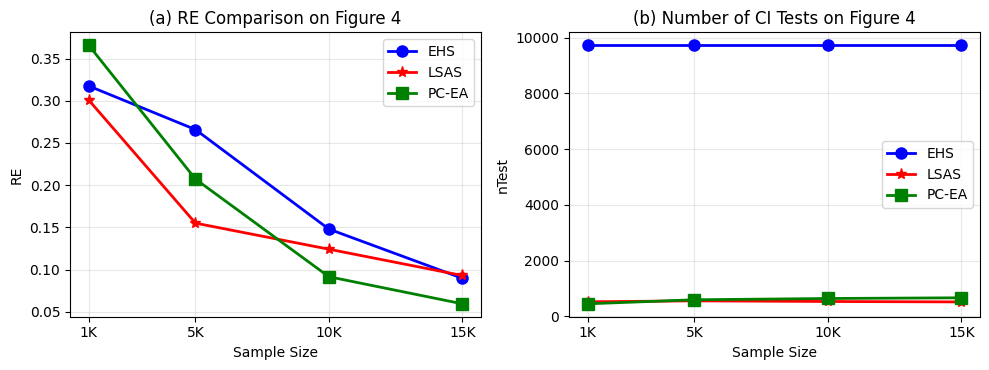

In [57]:
method_styles = {
    "LSAS": {
        "color": "red",
        "marker": "*"
    },
    "EHS": {
        "color": "blue",
        "marker": "o"
    },
    "PC-EA": {
        "color": "green",
        "marker": "s" 
    }
}

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

for method in summary_fig_4["method"].unique():
    df_method = summary_fig_4[summary_fig_4["method"] == method]

    style = method_styles.get(
        method,
        {"color": "black", "marker": "o"}
    )

    # RE 
    axes[0].plot(
        df_method["sample_size"],
        df_method["mean_RE"],
        marker=style["marker"],
        color=style["color"],
        linewidth=2,
        markersize=8,
        label=method
    )

    # nTest 
    axes[1].plot(
        df_method["sample_size"],
        df_method["mean_nTest"],
        marker=style["marker"],
        color=style["color"],
        linewidth=2,
        markersize=8,
        label=method
    )

axes[0].set_xlabel("Sample Size")
axes[0].set_ylabel("RE")
axes[0].set_title("(a) RE Comparison on Figure 4")
axes[0].set_xticks(sorted(summary["sample_size"].unique()))
axes[0].set_xticklabels(["1K", "5K", "10K", "15K"])
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_xlabel("Sample Size")
axes[1].set_ylabel("nTest")
axes[1].set_title("(b) Number of CI Tests on Figure 4")
axes[1].set_xticks(sorted(summary["sample_size"].unique()))
axes[1].set_xticklabels(["1K", "5K", "10K", "15K"])
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()